# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
# Import all required libraries
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
# Load the CIFAR-10 dataset directly from Keras
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Define the 10 class labels
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)   # (50000, 32, 32, 3)
print("Test shape:",  x_test.shape)    # (10000, 32, 32, 3)

A local file was found, but it seems to be incomplete or outdated because the auto file hash does not match the original value of 6d958be074577803d12ecdefd02955f39262c83c16fe9348329d7fe0b5c001ce so we will re-download the data.
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4219s 25us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

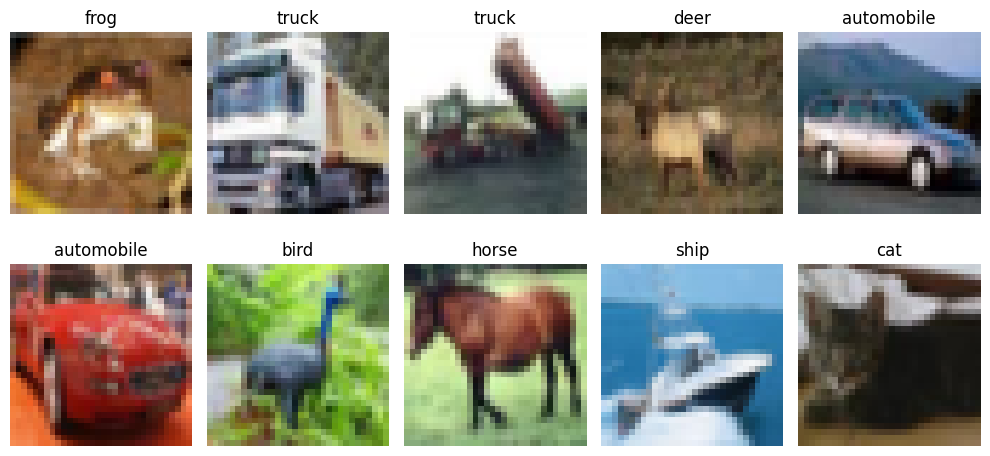

In [3]:
# Display the first 10 training images with their class labels
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
# Normalize pixel values from uint8 (0-255) to float32 (0.0-1.0)
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm  = x_test.astype('float32')  / 255.0

# Flatten images for the ANN (32x32x3 = 3072 features per image)
x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)  # shape: (50000, 3072)
x_test_flat  = x_test_norm.reshape(len(x_test_norm),  -1)   # shape: (10000, 3072)

print("Normalized train shape:", x_train_norm.shape)
print("Flattened train shape: ", x_train_flat.shape)

Normalized train shape: (50000, 32, 32, 3)
Flattened train shape:  (50000, 3072)


# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

Architecture:
- **Flatten** layer to convert 32×32×3 → 3072 features
- Multiple **Dense** layers with ReLU activation
- **Dropout** layers to reduce overfitting
- **Softmax** output layer for 10 classes

In [5]:
# ── ANN Model ────────────────────────────────────────────────────────────────
# Using a Flatten layer first so the model can also accept image-shaped inputs,
# then multiple Dense layers with Dropout for regularization.

ann_model = models.Sequential([
    # Flatten converts (32,32,3) images to a 1-D vector of 3072 values
    layers.Flatten(input_shape=(32, 32, 3)),

    # Dense layer 1 – large width to learn complex patterns
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),          # drop 30% neurons to reduce overfitting

    # Dense layer 2 – intermediate representation
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),

    # Dense layer 3 – further compression
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),

    # Output layer – 10 neurons, one per CIFAR-10 class
    layers.Dense(10, activation='softmax')
], name="ANN_Model")

# Compile with Adam optimizer and sparse categorical cross-entropy loss
ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Print model architecture summary
ann_model.summary()

C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "ANN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Train the ANN for 10 epochs with 10% validation split
ann_history = ann_model.fit(
    x_train_norm, y_train,   # use normalized image arrays (not flattened – Flatten layer handles it)
    epochs=10,
    validation_split=0.1,    # 10% of training data used for validation
    batch_size=64,
    verbose=1
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2263 - loss: 2.0769 - val_accuracy: 0.2954 - val_loss: 1.9102
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2816 - loss: 1.9401 - val_accuracy: 0.3302 - val_loss: 1.8718
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2965 - loss: 1.9022 - val_accuracy: 0.3344 - val_loss: 1.8597
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3064 - loss: 1.8769 - val_accuracy: 0.3318 - val_loss: 1.8400
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3117 - loss: 1.8650 - val_accuracy: 0.3582 - val_loss: 1.8024
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3193 - loss: 1.8471 - val_accuracy: 0.3596 - val_loss: 1.8010
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3283 - loss: 1.8386 - val_accuracy: 0.3640 - val_loss: 1.7872
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3319 - loss: 1.8261 - val_accuracy: 0.

In [7]:
# Evaluate ANN on the held-out test set
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"ANN Test Accuracy: {ann_test_acc*100:.2f}%")

ANN Test Accuracy: 38.99%


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [8]:
# ── CNN Model ─────────────────────────────────────────────────────────────────
# Three Conv2D blocks with increasing filters (32 → 64 → 128).
# BatchNormalization stabilizes training; MaxPooling reduces spatial dimensions.

cnn_model = models.Sequential([
    # ── Block 1: 32 filters ──────────────────────────────────────────────────
    layers.Conv2D(32, (3,3), activation='relu', padding='same',
                  input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # ── Block 2: 64 filters ──────────────────────────────────────────────────
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # ── Block 3: 128 filters ─────────────────────────────────────────────────
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    # ── Classifier head ───────────────────────────────────────────────────────
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name="CNN_Model")

# Compile with Adam optimizer
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Print model architecture summary
cnn_model.summary()

C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,144,138 (4.36 MB)

 Trainable params: 1,143,690 (4.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [9]:
# Train the CNN for 10 epochs
cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.4389 - loss: 1.5682 - val_accuracy: 0.5842 - val_loss: 1.1732
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.5950 - loss: 1.1521 - val_accuracy: 0.3294 - val_loss: 3.0229
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.6682 - loss: 0.9474 - val_accuracy: 0.6614 - val_loss: 0.9847
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.7201 - loss: 0.8038 - val_accuracy: 0.6086 - val_loss: 1.2675
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.7588 - loss: 0.6909 - val_accuracy: 0.6628 - val_loss: 1.0075
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.7924 - loss: 0.5959 - val_accuracy: 0.6880 - val_loss: 1.0514
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.8196 - loss: 0.5127 - val_accuracy: 0.7274 - val_loss: 0.8110
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.8407 - loss: 0.4508 - 

In [10]:
# Evaluate CNN on the test set
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"CNN Test Accuracy: {cnn_test_acc*100:.2f}%")

CNN Test Accuracy: 73.33%


## 📈 Compare Learning Curves
Plot ANN and CNN validation accuracy on the **same graph** to visually compare how well each model generalises.

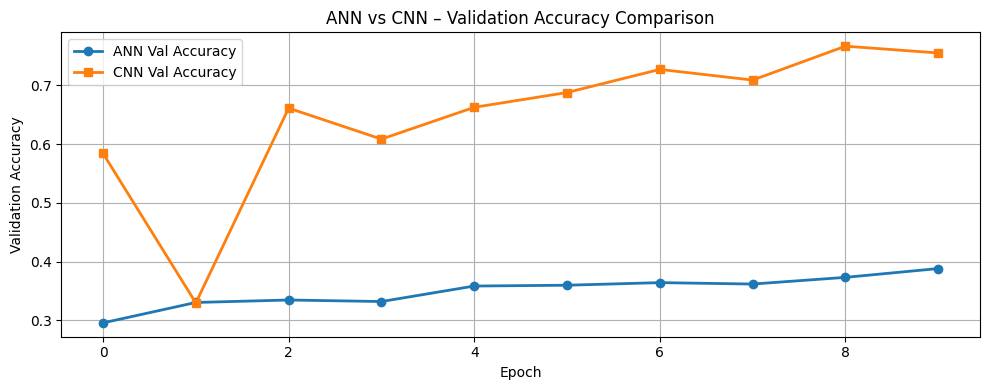

In [11]:
# ── Validation Accuracy Comparison Plot ───────────────────────────────────────
plt.figure(figsize=(10, 4))

plt.plot(ann_history.history['val_accuracy'], label='ANN Val Accuracy',
         marker='o', linewidth=2)
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Accuracy',
         marker='s', linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("ANN vs CNN – Validation Accuracy Comparison")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

Augmentation layers applied **only during training**:
- **RandomFlip** – randomly flips images horizontally
- **RandomRotation** – randomly rotates images by up to 10%
- **RandomZoom** – randomly zooms into images by up to 10%

In [12]:
# ── Data Augmentation Pipeline ────────────────────────────────────────────────
# These layers are only active during training and are skipped during inference.
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),   # mirror images left-right
    layers.RandomRotation(0.1),        # rotate up to +/-10% of 2pi
    layers.RandomZoom(0.1)             # zoom in/out up to 10%
], name="Data_Augmentation")

# ── Augmented CNN Model ───────────────────────────────────────────────────────
# Same architecture as the baseline CNN but with augmentation as the first block.
aug_cnn_model = models.Sequential([
    # Augmentation block (active only during training)
    data_augmentation,

    # ── Block 1: 32 filters ──────────────────────────────────────────────────
    layers.Conv2D(32, 3, activation='relu', padding='same',
                  input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # ── Block 2: 64 filters ──────────────────────────────────────────────────
    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # ── Block 3: 128 filters ─────────────────────────────────────────────────
    layers.Conv2D(128, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),

    # ── Classifier head ───────────────────────────────────────────────────────
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name="Aug_CNN_Model")

aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Print model architecture summary
aug_cnn_model.summary()

Model: "Aug_CNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Data_Augmentation (Sequential)  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

---
## ✅ Beginner Task 1 – Increase ANN Layers

**Goal:** Add more Dense layers to give the ANN more capacity to learn complex patterns.

Original ANN: 3 hidden layers (512 → 256 → 128)
Improved ANN: **4 hidden layers** (1024 → 512 → 256 → 128) ✔

---
## ✅ Beginner Task 2 – CNN Filters 32 → 64 → 128

**Goal:** Use progressively larger filter counts so the CNN learns increasingly complex features.

Both CNN models (baseline + augmented) use **32 → 64 → 128** filter progression. ✔

---
## ✅ Beginner Task 3 & 4 – 20 Epochs + EarlyStopping

**Goal:** Train longer (up to 20 epochs) but auto-stop when validation loss stops improving.

The augmented CNN is trained with `epochs=20` and `EarlyStopping(patience=3)`. ✔

---
## ✅ Beginner Task 5 – Data Augmentation Training

**Goal:** Use random image transformations during training to reduce overfitting.

The `aug_cnn_model` includes RandomFlip, RandomRotation, and RandomZoom layers
that apply only during training, not during evaluation. ✔

In [13]:
# ==============================================================================
# BEGINNER TASK 1: Increase ANN Layers (1024 -> 512 -> 256 -> 128)
# ==============================================================================
# We add a 4th Dense layer (1024 units) compared to the original 3-layer ANN.
# More layers = deeper representation = better ability to learn complex patterns.

improved_ann_model = models.Sequential([
    # Flatten: (32,32,3) -> 3072-dimensional vector
    layers.Flatten(input_shape=(32, 32, 3)),

    # --- NEW extra layer (not in original ANN) ---
    layers.Dense(1024, activation='relu'),
    layers.Dropout(0.3),

    # Layer 2
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),

    # Layer 3
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),

    # Layer 4
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),

    # Output: 10 classes
    layers.Dense(10, activation='softmax')
], name="Improved_ANN_4Layers")

improved_ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Summary shows 4 hidden Dense layers instead of original 3
improved_ann_model.summary()

Model: "Improved_ANN_4Layers"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,837,066 (14.64 MB)

 Trainable params: 3,837,066 (14.64 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Train the Improved ANN (Task 1)
improved_ann_history = improved_ann_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

# Evaluate on test set
imp_ann_loss, imp_ann_acc = improved_ann_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"\nImproved ANN (4 layers) Test Accuracy: {imp_ann_acc*100:.2f}%")

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.2069 - loss: 2.1024 - val_accuracy: 0.2998 - val_loss: 1.9221
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.2727 - loss: 1.9521 - val_accuracy: 0.3212 - val_loss: 1.8709
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.2956 - loss: 1.9062 - val_accuracy: 0.3246 - val_loss: 1.8683
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.3098 - loss: 1.8810 - val_accuracy: 0.3394 - val_loss: 1.8442
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.3126 - loss: 1.8714 - val_accuracy: 0.3630 - val_loss: 1.8095
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.3269 - loss: 1.8406 - val_accuracy: 0.3406 - val_loss: 1.8340
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.3311 - loss: 1.8275 - val_accuracy: 0.3624 - val_loss: 1.7783
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.3344 - loss: 1.8193 - v

In [15]:
# ==============================================================================
# BEGINNER TASK 4: EarlyStopping callback
# ==============================================================================
# Monitors val_loss. If it does not improve for 3 epochs in a row,
# training stops automatically and best weights are restored.
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# ==============================================================================
# BEGINNER TASK 3 + TASK 5: Train Augmented CNN for up to 20 epochs
# ==============================================================================
# Task 3: epochs=20 (train longer)
# Task 4: callbacks=[early_stop] (auto-stop if no improvement)
# Task 5: aug_cnn_model has data augmentation built into its first layer
aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,               # Task 3: up to 20 epochs
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop],  # Task 4: stops early if val_loss stagnates
    verbose=1                # Task 5: augmentation runs inside the model
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step - accuracy: 0.3589 - loss: 1.7818 - val_accuracy: 0.3958 - val_loss: 1.8042
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.4641 - loss: 1.4782 - val_accuracy: 0.5092 - val_loss: 1.4854
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.5274 - loss: 1.3338 - val_accuracy: 0.5666 - val_loss: 1.2546
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.5660 - loss: 1.2350 - val_accuracy: 0.6080 - val_loss: 1.0821
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.5921 - loss: 1.1650 - val_accuracy: 0.5724 - val_loss: 1.3642
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.6101 - loss: 1.1137 - val_accuracy: 0.6114 - val_loss: 1.1853
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.6338 - loss: 1.0565 - val_accuracy: 0.5802 - val_loss: 1.3778
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 4.


In [16]:
# Evaluate the Augmented CNN on the test set
aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"CNN + Data Augmentation Test Accuracy: {aug_test_acc*100:.2f}%")

CNN + Data Augmentation Test Accuracy: 60.18%


## 📈 Validation Accuracy – All Three Models
Overlay all three models on one graph to compare learning dynamics.

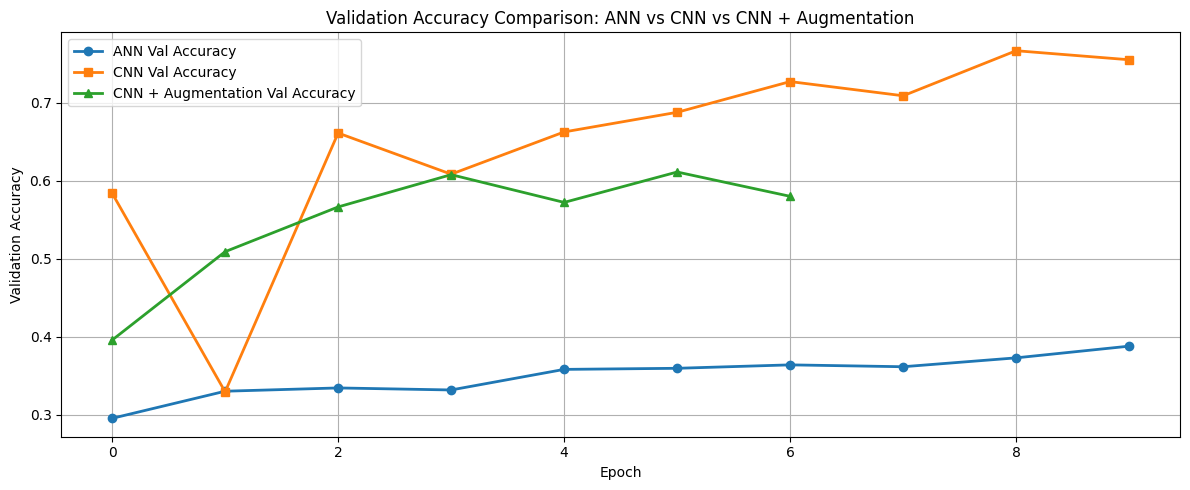

In [17]:
# ── Validation Accuracy Comparison – All Models ───────────────────────────────
plt.figure(figsize=(12, 5))

plt.plot(ann_history.history['val_accuracy'],
         label='ANN Val Accuracy', marker='o', linewidth=2)
plt.plot(cnn_history.history['val_accuracy'],
         label='CNN Val Accuracy', marker='s', linewidth=2)
plt.plot(aug_history.history['val_accuracy'],
         label='CNN + Augmentation Val Accuracy', marker='^', linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison: ANN vs CNN vs CNN + Augmentation")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 📊 Final Comparison Table
Summarise test accuracy across all three models using a Pandas DataFrame.

In [18]:
# ── Final Accuracy Comparison DataFrame ───────────────────────────────────────
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN", "CNN + Data Augmentation"],
    "Test Accuracy": [
        f"{ann_test_acc*100:.2f}%",
        f"{cnn_test_acc*100:.2f}%",
        f"{aug_test_acc*100:.2f}%"
    ]
})

print("\n=== Model Comparison ===")
comparison


=== Model Comparison ===


,Model,Test Accuracy
0,ANN,38.99%
1,CNN,73.33%
2,CNN + Data Augmentation,60.18%


# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**